# 1 加载数据 

In [69]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#设置sns格式
sns.set(style='white',context='notebook',palette='muted')
#导入数据
train =pd.read_csv('/kaggle/input/datasets/dekern/kaggle/train.csv')
test= pd.read_csv('/kaggle/input/datasets/dekern/kaggle/test.csv')
display(train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2 数据探索

## 2.1 数据查看  

In [70]:
#查看数据集
print('训练数据大小：',train.shape)
print('预测数据大小：',test.shape)

训练数据大小： (891, 12)
预测数据大小： (418, 11)


In [71]:
display(train.head(),test.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2.2 数据合并 

In [72]:
#合并训练数据和测试数据
full = pd.concat([train, test], ignore_index=True)
print('\n合并后数据基本统计：')
print(full.describe())


合并后数据基本统计：
       PassengerId    Survived       Pclass          Age        SibSp  \
count  1309.000000  891.000000  1309.000000  1046.000000  1309.000000   
mean    655.000000    0.383838     2.294882    29.881138     0.498854   
std     378.020061    0.486592     0.837836    14.413493     1.041658   
min       1.000000    0.000000     1.000000     0.170000     0.000000   
25%     328.000000    0.000000     2.000000    21.000000     0.000000   
50%     655.000000    0.000000     3.000000    28.000000     0.000000   
75%     982.000000    1.000000     3.000000    39.000000     1.000000   
max    1309.000000    1.000000     3.000000    80.000000     8.000000   

             Parch         Fare  
count  1309.000000  1308.000000  
mean      0.385027    33.295479  
std       0.865560    51.758668  
min       0.000000     0.000000  
25%       0.000000     7.895800  
50%       0.000000    14.454200  
75%       0.000000    31.275000  
max       9.000000   512.329200  


## 2.3 查看info()详情 

In [73]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


## 2.4 特征与标签之间的关系 

<Axes: xlabel='Embarked', ylabel='Survived'>

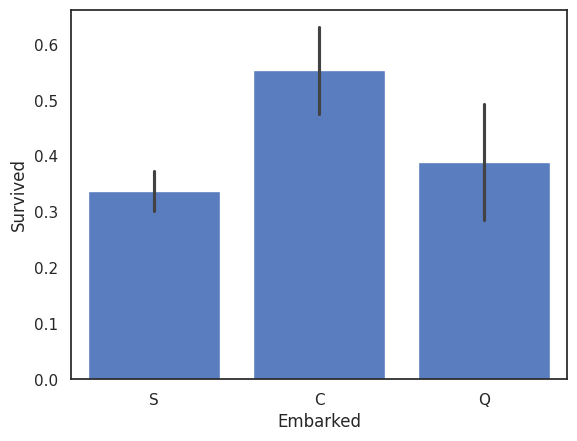

In [74]:
#港口和生死之间的关系
sns.barplot(data=train,x='Embarked',y='Survived')

In [75]:
#计算不同类型Embarked的乘客其生存率是多少
s = full.groupby('Embarked')['Survived'].value_counts().to_frame()
display(s)
s2 = s.groupby(level=0).transform(lambda x: x / x.sum())
display(s2)
result = pd.merge(s, s2, left_index=True,right_index=True,suffixes=['_num','_rate'])
display(result)

count
Embarked Survived       
C        1.0          93
         0.0          75
Q        0.0          47
         1.0          30
S        0.0         427
         1.0         217

count
Embarked Survived          
C        1.0       0.553571
         0.0       0.446429
Q        0.0       0.610390
         1.0       0.389610
S        0.0       0.663043
         1.0       0.336957

count_num  count_rate
Embarked Survived                       
C        1.0              93    0.553571
         0.0              75    0.446429
Q        0.0              47    0.610390
         1.0              30    0.389610
S        0.0             427    0.663043
         1.0             217    0.336957

##  2.4.1 港口和生还率的关系  

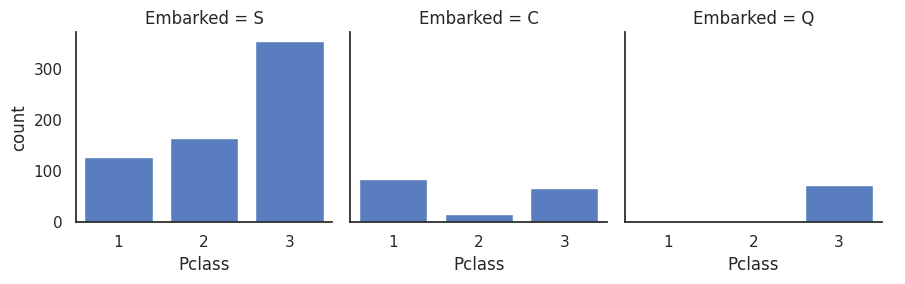

In [76]:
sns.catplot(x='Pclass',col='Embarked',data=train,kind='count',height=3)

## 2.4.2 家长和孩子数量与生还的关系  

<Axes: xlabel='Parch', ylabel='Survived'>

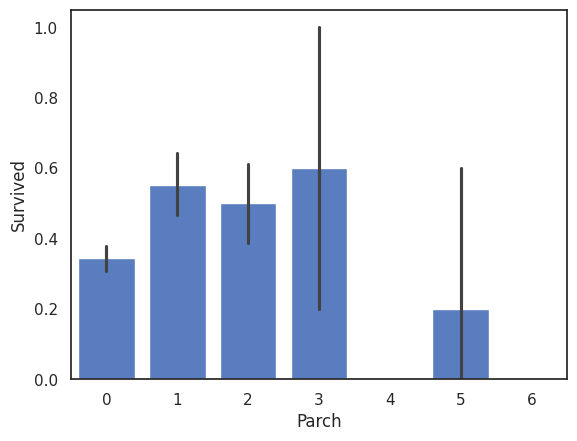

In [77]:
sns.barplot(data=train,x='Parch',y='Survived')

## 2.4.3 乘客花费与生死之间关系  

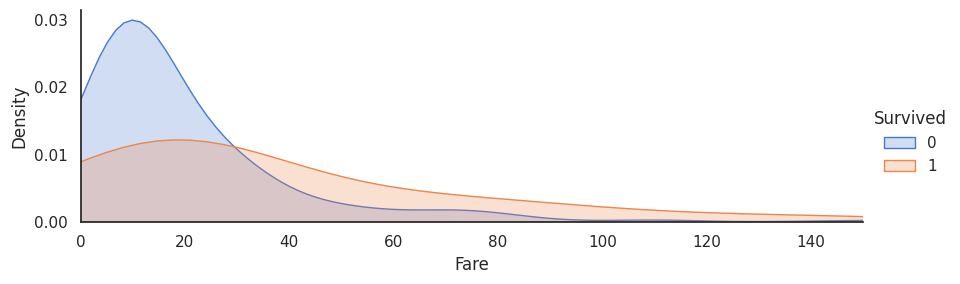

In [78]:
#创建坐标轴
ageFacet=sns.FacetGrid(train,hue='Survived',aspect=3)#aspect每个图片的纵横化
ageFacet.map(sns.kdeplot,'Fare',shade=True)
ageFacet.set(xlim=(0,150))
ageFacet.add_legend()

当票价低时乘客生存率较低，票价高时生存率一般越高

## 2.4.4 票价分布 

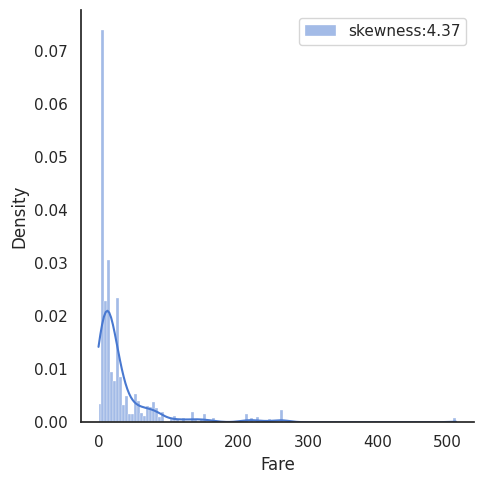

In [79]:
#查看fare分布
farePlot=sns.displot(full['Fare'][full['Fare'].notnull()],kde=True,stat='density',
                                label=f'skewness:{full['Fare'].skew():.2f}')
farePlot.ax.legend(loc='best')

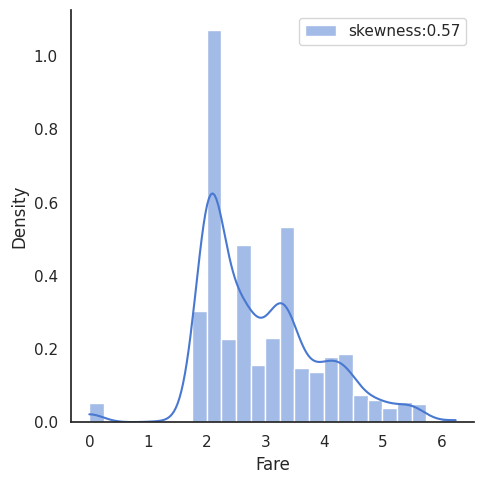

In [80]:
#对数化处理fare值
full['Fare']=full['Fare'].map(lambda x:np.log(x) if x>0 else x)

#处理之后票价Fare分布
farePlot=sns.displot(full['Fare'][full['Fare'].notnull()],kde=True,stat='density',
                                label=f'skewness:{full['Fare'].skew():.2f}')
farePlot.ax.legend(loc='best')
plt.savefig('./10-Fare票价分布.png',dpi=200)

## 2.5 数据预处理 

## 2.5.1 数据清洗  

In [81]:
full.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


## 2.5.1 Cabin缺失值处理  

In [82]:
#对Cabin缺失值进行处理,利用(Unknown)填充缺失值
full['Cabin']=full['Cabin'].fillna('U')
full['Cabin'].head()

0       U
1     C85
2       U
3    C123
4       U
Name: Cabin, dtype: object

## 2.5.2 Embarked缺失值处理

In [83]:
#对Embarked缺失值进行处理查看缺失值情况
display(full[full['Embarked'].isnull()])

display(full['Embarked'].value_counts())
#查看Embarked数据分布情况，可知在英国南安普斯顿登船可能性最大，因此以此填充缺失值
full['Embarked']=full['Embarked'].fillna('S')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,4.382027,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,4.382027,B28,NaN


Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

## 2.5.3 Fare缺失值填充 

In [84]:
# 查看缺失数据情况，该乘客乘坐3等舱，登船港口为法国，舱位未知
display(full[full['Fare'].isnull()])

# 利用3等舱，登船港口为英国，舱位未知旅客的平均票价来填充缺失值。
price = full[(full['Pclass']==3) & (full['Embarked']=='S') & (full['Cabin']=='U')]['Fare'].mean()
full['Fare'] = full['Fare'].fillna(price)
full.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,U,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


##   2.6 特征工程


##   2.6.1 头衔

In [85]:
# 构造新特征Title
full['Title'] = full['Name'].map(lambda x: x.split(',')[1].split('.')[0].strip())
# 查看title数据分布
full['Title'].value_counts()

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [86]:
# 将title信息进行整合
TitleDict = {}
TitleDict['Mr'] = 'Mr'
TitleDict['Mlle'] = 'Miss'
TitleDict['Miss'] = 'Miss'
TitleDict['Master'] = 'Master'
TitleDict['Jonkheer'] = 'Master'
TitleDict['Mme'] = 'Mrs'
TitleDict['Ms'] = 'Mrs'
TitleDict['Mrs'] = 'Mrs'
TitleDict['Don'] = 'Royalty'
TitleDict['Sir'] = 'Royalty'
TitleDict['the Countess'] = 'Royalty'
TitleDict['Dona'] = 'Royalty'
TitleDict['Lady'] = 'Royalty'
TitleDict['Capt'] = 'Officer'
TitleDict['Col'] = 'Officer'
TitleDict['Major'] = 'Officer'
TitleDict['Dr'] = 'Officer'
TitleDict['Rev'] = 'Officer'

full['Title'] = full['Title'].map(TitleDict)
full['Title'].value_counts()

Title
Mr         757
Miss       262
Mrs        200
Master      62
Officer     23
Royalty      5
Name: count, dtype: int64

<Axes: xlabel='Title', ylabel='Survived'>

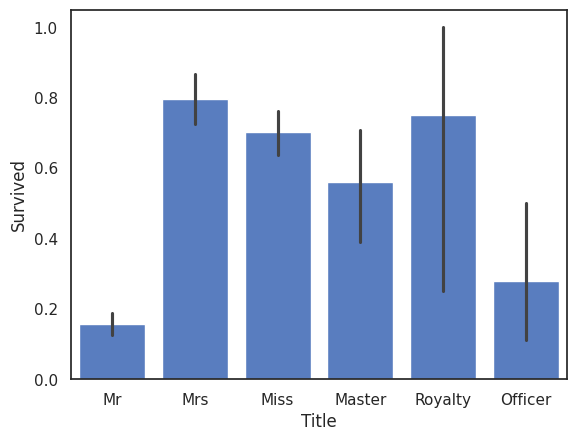

In [87]:
#可视化分析Title与Survived之间关系
sns.barplot(data=full,x='Title',y='Survived')

##  2.6.2 家庭成员数量 

<Axes: xlabel='familyNum', ylabel='Survived'>

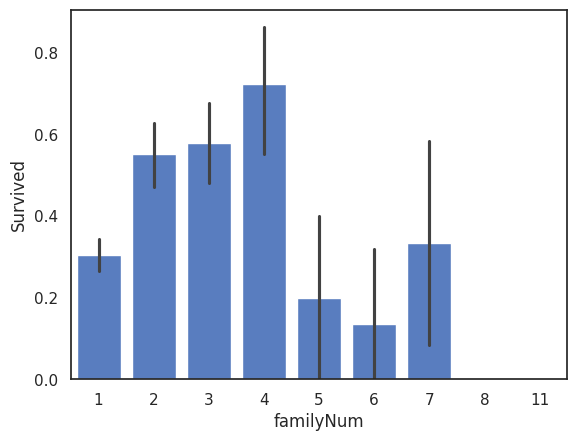

In [88]:
full['familyNum']=full['Parch']+full['SibSp']+1
#查看familyNum与Survived
sns.barplot(data=full,x='familyNum',y='Survived')

In [89]:
#我们按照家庭成员数量，把家庭规模分为小(0)、中(1)、大（2）三类
def familysize(familyNum):
    if familyNum==1:
        return 0
    elif(familyNum>=2)&(familyNum<=4):
        return 1
    else:
        return 2

full['familySize']=full['familyNum'].map(familysize)
full['familySize'].value_counts()

familySize
0    790
1    437
2     82
Name: count, dtype: int64

<Axes: xlabel='familySize', ylabel='Survived'>

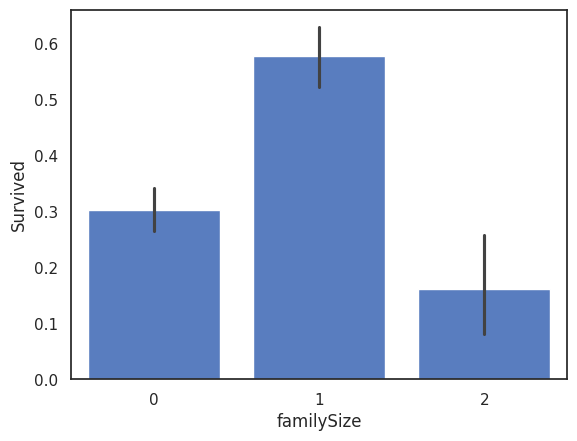

In [90]:
#查看familySize与Survived
sns.barplot(data=full,x='familySize',y='Survived')


当家庭规模适中时，乘客的生存率更高。

##    2.6.3 船舱类型   

In [91]:
full['Cabin'].unique()

array(['U', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

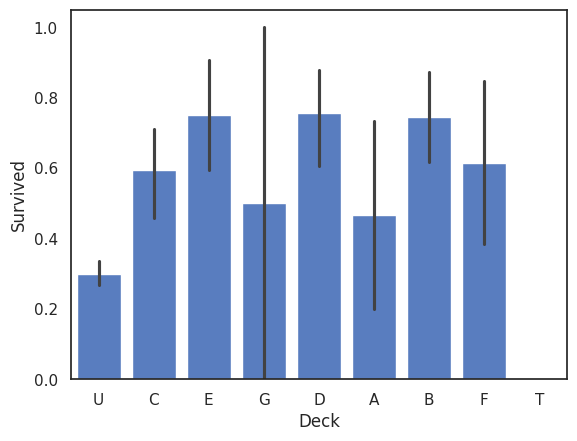

In [92]:
#提取Cabin字段首字母
full['Deck']=full['Cabin'].map(lambda x:x[0])
#查看不同Deck类型乘客的生存率
sns.barplot(data=full,x='Deck',y='Survived')
plt.savefig('./14-Deck与Survived关系。png',dpi=200)

当乘客的客舱类型为B/D/E时，生存率较高；当客舱类型为U/T，生存率较低

## 2.6.4 共号票乘客数量TickCom及TickGroup  

In [93]:
# 提取各票号的乘客数量
TickCountDict = full['Ticket'].value_counts()
TickCountDict.head()

Ticket
CA. 2343        11
1601             8
CA 2144          8
347082           7
S.O.C. 14879     7
Name: count, dtype: int64

<Axes: xlabel='TickCom', ylabel='Survived'>

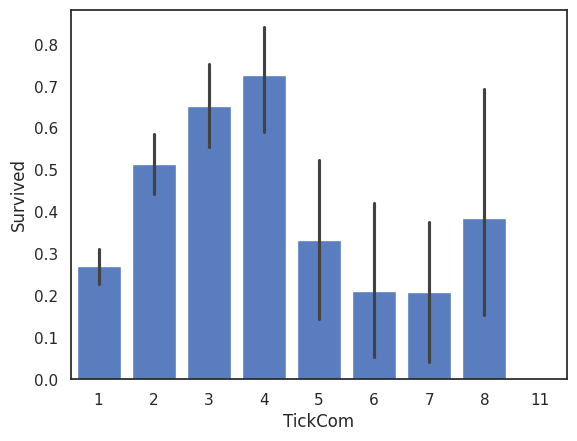

In [94]:
# 将同票号乘客数量数据并入数据集中
full['TickCom'] = full['Ticket'].map(TickCountDict)
full['TickCom'].head()

# 查看TickCom与Survived之间关系
import seaborn as sns
sns.barplot(data=full, x='TickCom', y='Survived')

当TickCom大小适中时，乘客生存率高

In [95]:
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,familyNum,familySize,Deck,TickCom
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,U,S,Mr,2,1,U,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,Mrs,2,1,C,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,U,S,Miss,1,0,U,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,Mrs,2,1,C,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,U,S,Mr,1,0,U,1


<Axes: xlabel='TickGroup', ylabel='Survived'>

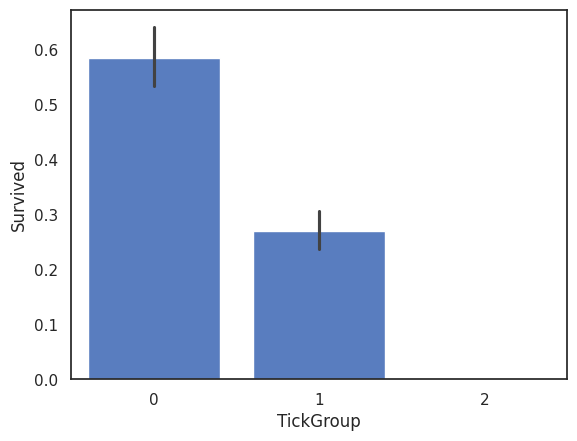

In [96]:
# 按照TickCom大小，将TickGroup分为三类
def TickCountGroup(num):
    if (num>=2)&(num<=4):
        return 0
    elif (num==1)|((num>=5)&(num<=8)):
        return 1
    else:
        return 2

# 得到各位乘客TickGroup的类别
full['TickGroup']=full['TickCom'].map(TickCountGroup)

# 查看TickGroup与Survived之间关系
sns.barplot(data=full,x='TickGroup',y='Survived')

## 2.7 填充Age年龄

In [97]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
 12  Title        1309 non-null   object 
 13  familyNum    1309 non-null   int64  
 14  familySize   1309 non-null   int64  
 15  Deck         1309 non-null   object 
 16  TickCom      1309 non-null   int64  
 17  TickGroup    1309 non-null   int64  
dtypes: float64(3), int64(8), object(7)
memory usage:

In [98]:
# 只保留数值列，再计算相关系数
full[full['Age'].notnull()].select_dtypes(include=['number']).corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,familyNum,familySize,TickCom,TickGroup
PassengerId,1.000000,0.029340,-0.064097,0.028814,-0.050700,-0.021096,0.038722,-0.044024,-0.048093,-0.013838,-0.005325
Survived,0.029340,1.000000,-0.359653,-0.077221,-0.017358,0.093317,0.342920,0.042787,0.106359,0.093239,-0.322862
Pclass,-0.064097,-0.359653,1.000000,-0.408106,0.047221,0.017224,-0.741394,0.039602,-0.074864,-0.114293,0.311226
Age,0.028814,-0.077221,-0.408106,1.000000,-0.243699,-0.150917,0.194038,-0.240229,-0.174901,-0.185284,-0.005224
SibSp,-0.050700,-0.017358,0.047221,-0.243699,1.000000,0.374456,0.294004,0.844260,0.779310,0.621362,-0.131130
Parch,-0.021096,0.093317,0.017224,-0.150917,0.374456,1.000000,0.318137,0.813080,0.705738,0.641500,-0.162860
Fare,0.038722,0.342920,-0.741394,0.194038,0.294004,0.318137,1.000000,0.368463,0.451368,0.603769,-0.439788
familyNum,-0.044024,0.042787,0.039602,-0.240229,0.844260,0.813080,0.368463,1.000000,0.897180,0.760887,-0.176458
familySize,-0.048093,0.106359,-0.074864,-0.174901,0.779310,0.705738,0.451368,0.897180,1.000000,0.661291,-0.401090
TickCom,-0.013838,0.093239,-0.114293,-0.185284,0.621362,0.641500,0.603769,0.760887,0.661291,1.000000,-0.203938


In [99]:
# 筛选数据集
agePre = full[['Age', 'Parch', 'Pclass', 'SibSp', 'familyNum', 'TickCom', 'Title']]

# 进行one-hot编码
agePre = pd.get_dummies(agePre)

# 计算相关性矩阵
ageCorrDf = agePre.corr()

# 提取与Age的相关系数并排序
ageCorrDf['Age'].sort_values()

Pclass          -0.408106
Title_Master    -0.385380
Title_Miss      -0.282977
SibSp           -0.243699
familyNum       -0.240229
TickCom         -0.185284
Parch           -0.150917
Title_Royalty    0.057337
Title_Officer    0.166771
Title_Mr         0.183965
Title_Mrs        0.215091
Age              1.000000
Name: Age, dtype: float64

In [100]:
agePre.head()

,Age,Parch,Pclass,SibSp,familyNum,TickCom,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
0,22.0,0,3,1,2,1,False,False,True,False,False,False
1,38.0,0,1,1,2,2,False,False,False,True,False,False
2,26.0,0,3,0,1,1,False,True,False,False,False,False
3,35.0,0,1,1,2,2,False,False,False,True,False,False
4,35.0,0,3,0,1,1,False,False,True,False,False,False


In [101]:
# 拆分实验集和预测集
ageKnown = agePre[agePre['Age'].notnull()]#根据非空数据，规律
ageUnknown = agePre[agePre['Age'].isnull()]#空数据，填充

# 生成实验数据的特征和标签
ageKnown_X = ageKnown.drop(['Age'], axis=1)
ageKnown_y = ageKnown['Age']

# 生成预测数据的特征
ageUnknown_X = ageUnknown.drop(['Age'], axis=1)

# 利用随机森林构建模型
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=None, n_estimators=500, n_jobs=-1)
rfr.fit(ageKnown_X, ageKnown_y)

RandomForestRegressor(n_estimators=500, n_jobs=-1)

In [102]:
# 模型得分
score = rfr.score(ageKnown_X, ageKnown_y)
print('模型预测年龄得分是：', score)

# 预测年龄
ageUnknown_predict = rfr.predict(ageUnknown_X)

# 填充预测数据
full.loc[full['Age'].isnull(), ['Age']] = ageUnknown_predict

full.info()  # 此时已无缺失值


模型预测年龄得分是： 0.5864660830045303
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
 12  Title        1309 non-null   object 
 13  familyNum    1309 non-null   int64  
 14  familySize   1309 non-null   int64  
 15  Deck         1309 non-null   object 
 16  TickCom      1309 non-null   int64  
 17  TickGroup    1309 non-null   int64  
dtypes: float64(3), int

##  2.8   同组识别

In [103]:
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,familyNum,familySize,Deck,TickCom,TickGroup
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,U,S,Mr,2,1,U,1,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,Mrs,2,1,C,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,U,S,Miss,1,0,U,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,Mrs,2,1,C,2,0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,U,S,Mr,1,0,U,1,1


In [104]:
#提取乘客的姓氏及相应的乘客数
full['Surname']=full['Name'].map(lambda x:x.split(',')[0].strip())
SurnameDict=full['Surname'].value_counts()
#display(SurnameDict)
full['SurnameNum']=full['Surname'].map(SurnameDict)

#12岁以上男性：找出男性中同姓氏均获救的部分
MaleDf = full[(full['Sex'] == 'male') & (full['Age'] > 12) & (full['familyNum'] >= 2)]
             
#分析男性同组效应
MSurNamDf=MaleDf['Survived'].groupby(MaleDf['Surname']).mean()
MSurNamDf.head()
MSurNamDf.value_counts()

Survived
0.0    89
1.0    19
0.5     3
Name: count, dtype: int64

大多数同姓氏男性存在‘同生共死’的特点，利用同组效应，对生存率为1的姓氏里的男性数据进行修正，提升其预测为“可以幸存”的概率

In [105]:
# 提取乘客的姓氏及相应的乘客数
full['Surname'] = full['Name'].map(lambda x:x.split(',')[0].strip())
SurNameDict = full['Surname'].value_counts()
full['SurnameNum'] = full['Surname'].map(SurNameDict)

# 将数据分为两组
FemChildDf = full[((full['Sex']=='female')|(full['Age']<=12))&(full['familyNum']>=2)]

# 按姓氏分组计算存活率，并计算不同存活率的人数分布
FCSurNamDf = FemChildDf['Survived'].groupby(FemChildDf['Surname']).mean()
FCSurNamDf.head()
FCSurNamDf.value_counts()

Survived
1.000000    115
0.000000     27
0.750000      2
0.333333      1
0.142857      1
Name: count, dtype: int64

女性及儿童也存在同生共死的情况，利用同组效应对生存率为0的形式里的女性及儿童提升其预测为“并未幸存”的概率

In [106]:
# 获得生存率为1的姓氏
MSurNamDict = MSurNamDf[MSurNamDf.values == 1].index
MSurNamDict

# 获得生存率为0的姓氏
FCSurNamDict = FCSurNamDf[FCSurNamDf.values == 0].index
FCSurNamDict

# 对数据集中这些姓氏的男性数据进行修正：1、性别改为女；2、年龄改为5
full.loc[(full['Survived'].isnull()) & (full['Surname'].isin(MSurNamDict)) & (full['Sex'] == 'male'), 'Sex'] = 'female'
full.loc[(full['Survived'].isnull()) & (full['Surname'].isin(MSurNamDict)) & (full['Sex'] == 'male'), 'Age'] = 5

# 对数据集中这些姓氏的女性及儿童的数据进行修正：1、性别改为男；2、年龄改为60
full.loc[(full['Survived'].isnull()) & (full['Surname'].isin(FCSurNamDict)) & ((full['Sex'] == 'female') | (full['Age'] <= 12)), 'Sex'] = 'male'
full.loc[(full['Survived'].isnull()) & (full['Surname'].isin(FCSurNamDict)) & ((full['Sex'] == 'female') | (full['Age'] <= 12)), 'Age'] = 60

## 2.9 条件筛选 

In [107]:
#full['Sex'] = full['Sex'].map({'male':0, 'female':1})
#full['Embarked'] = full['Embarked'].map({'S':0, 'C':1, 'Q':2})
# 人工筛选
fullSel = full.drop(['Cabin','Name','Ticket','PassengerId','Surname','SurnameNum','Embarked','Sex'], axis=1)

#查看各特征与标签相关性
corrDf=pd.DataFrame()#新建空表格
corrDf = fullSel.corr(numeric_only=True)
corrDf['Survived'].sort_values(ascending=True)

Pclass       -0.338481
TickGroup    -0.319278
Age          -0.059759
SibSp        -0.035322
familyNum     0.016639
TickCom       0.064962
Parch         0.081629
familySize    0.108631
Fare          0.331805
Survived      1.000000
Name: Survived, dtype: float64

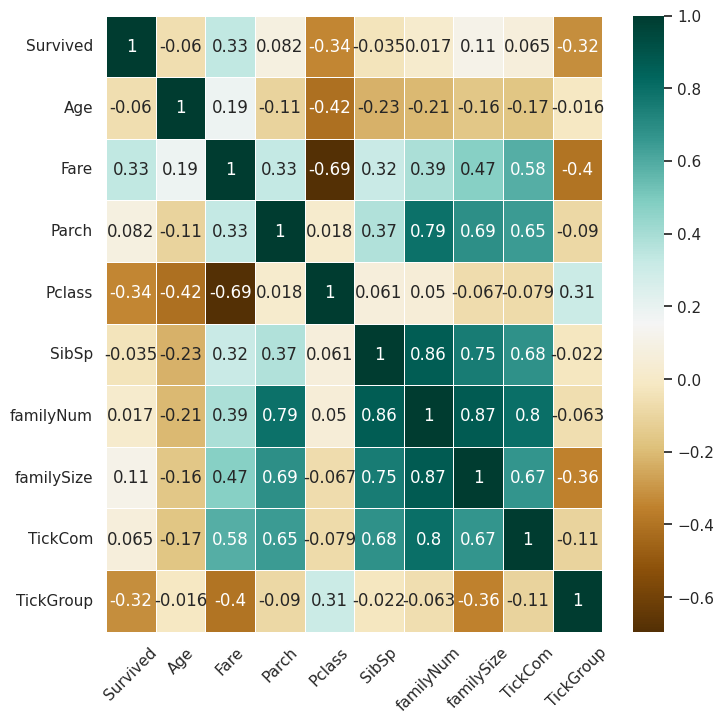

In [108]:
# 热力图，查看Survived与其他特征间相关性大小
plt.figure(figsize=(8, 8))
sns.heatmap(fullSel[['Survived','Age','Fare','Parch','Pclass',
                     'SibSp','familyNum','familySize',
                     'TickCom','TickGroup']].corr(), cmap='BrBG', annot=True,
            linewidths=.5)
_ = plt.xticks(rotation=45)
#plt.show()

# 3 算法建模

## 3.1  模型选择

In [109]:
# 拆分实验数据与预测数据
experData = fullSel[fullSel['Survived'].notnull()]
preData = fullSel[fullSel['Survived'].isnull()]

experData_X = experData.drop('Survived', axis=1)
experData_y = experData['Survived']
preData_X = preData.drop('Survived', axis=1)  # 空数据

experData_X = experData_X.select_dtypes(include=['number'])
preData_X = preData_X.select_dtypes(include=['number'])

# 导入机器学习算法库
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

# 设置kfold，交叉采样法拆分数据集
kfold = StratifiedKFold(n_splits=10)

# 汇总不同模型算法
classifiers = []
classifiers.append(SVC())
classifiers.append(DecisionTreeClassifier())
classifiers.append(RandomForestClassifier())
classifiers.append(ExtraTreesClassifier())
classifiers.append(GradientBoostingClassifier())
classifiers.append(KNeighborsClassifier())
classifiers.append(LogisticRegression(
    solver='saga',
    max_iter=5000,
    random_state=42
))
classifiers.append(LinearDiscriminantAnalysis())
classifiers.append(XGBClassifier())

In [110]:

# 不同机器学习交叉验证结果汇总
cv_results = []
for classifier in classifiers:
    cv_results.append(cross_val_score(classifier, experData_X, experData_y,
                                      scoring='accuracy', cv=kfold, n_jobs=-1))

# 求出模型得分的均值和标准差
cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

# 汇总数据
cvResDf = pd.DataFrame({'cv_mean': cv_means,
                        'cv_std': cv_std,
                        'algorithm': ['SVC', 'DecisionTreeCla', 'RandomForestCla',
                                      'ExtraTreesCla', 'GradientBoostingCla',
                                      'KNN', 'LR', 'LDA','Xgboost']})
cvResDf

,cv_mean,cv_std,algorithm
0,0.673383,0.026983,SVC
1,0.666679,0.030835,DecisionTreeCla
2,0.720562,0.021822,RandomForestCla
3,0.708177,0.023736,ExtraTreesCla
4,0.737416,0.040562,GradientBoostingCla
5,0.705955,0.038136,KNN
6,0.736355,0.041826,LR
7,0.735243,0.050202,LDA
8,0.693620,0.040057,Xgboost


(0.6, 0.85)

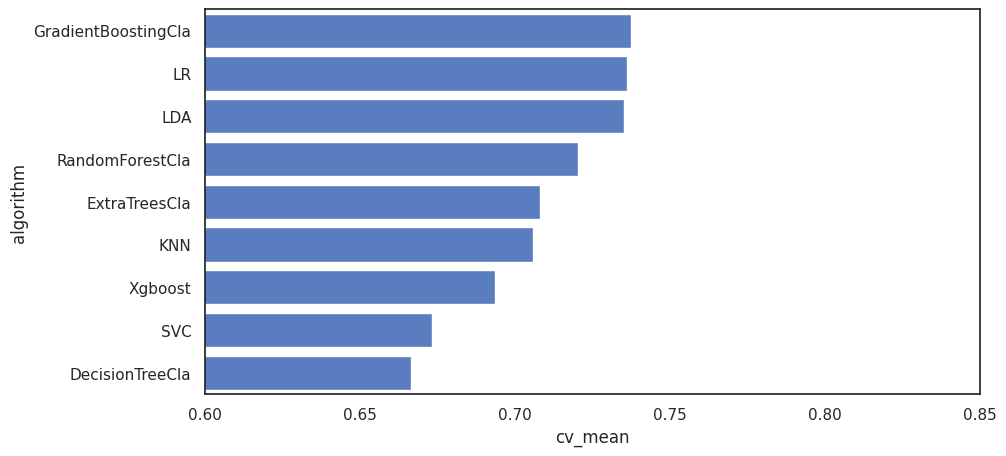

In [111]:
# 自动按准确率从高到低排序
df_sorted = cvResDf.sort_values("cv_mean", ascending=False)

# 画图
plt.figure(figsize=(10,5))
sns.barplot(data=df_sorted, x="cv_mean", y="algorithm")

# X轴范围
plt.xlim(0.6, 0.85)

## 3.2 模型调优 

In [112]:
#GradientBoostingClassifier模型
GBC = GradientBoostingClassifier()
gb_param_grid = {'loss' : ["log_loss"],
              'n_estimators' : [100,200,300],
              'learning_rate': [0.1, 0.05, 0.01],
              'max_depth': [4, 8],
              'min_samples_leaf': [100,150],
              'max_features': [0.3, 0.1]
              }
modelgsGBC = GridSearchCV(GBC,param_grid = gb_param_grid, cv=kfold,
                                     scoring="accuracy", n_jobs= -1, verbose = 1)
modelgsGBC.fit(experData_X,experData_y)
print(float(modelgsGBC.best_score_))

Fitting 10 folds for each of 72 candidates, totalling 720 fits
0.7340948813982522


In [113]:
#LogisticRegression模型
modelLR = LogisticRegression(
    solver='saga',    # 支持 L1 正则
    max_iter=5000,    # 👈 把迭代次数拉满！
    random_state=42
)
LR_param_grid = {'C' : [1,2,3],
                  'penalty':['l1','l2']}
modelgsLR = GridSearchCV(modelLR,param_grid = LR_param_grid, cv=kfold,
                                     scoring="accuracy", n_jobs= -1, verbose = 1)
modelgsLR.fit(experData_X,experData_y)
print(float(modelgsLR.best_score_))

Fitting 10 folds for each of 6 candidates, totalling 60 fits
0.736354556803995


In [114]:
#SVC模型
svc = SVC()
gb_param_grid = {'C' : [0.1,0.5,1,2,3,5,10],
                 'kernel':['rbf','poly','sigmoid']
                 }
modelgsSVC = GridSearchCV(svc,param_grid = gb_param_grid, cv=kfold,
                                     scoring="accuracy", n_jobs= -1, verbose = 1)
modelgsSVC.fit(experData_X,experData_y)
print(float(modelgsSVC.best_score_))

Fitting 10 folds for each of 21 candidates, totalling 210 fits
0.7295880149812733


In [115]:
#LDA模型
lda = LinearDiscriminantAnalysis()
gb_param_grid = {'solver' : ['svd', 'lsqr', 'eigen'],
                  'tol':[0.00001, 0.0001, 0.001, 0.01, 0.01]
                 }
modelgsLDA = GridSearchCV(lda, param_grid = gb_param_grid, cv=kfold,
                                     scoring="accuracy", n_jobs= -1, verbose = 1)
modelgsLDA.fit(experData_X,experData_y)
print(float(modelgsLDA.best_score_))

Fitting 10 folds for each of 15 candidates, totalling 150 fits
0.7352434456928838


## 3.3 模型评估

<Figure size 640x480 with 0 Axes>

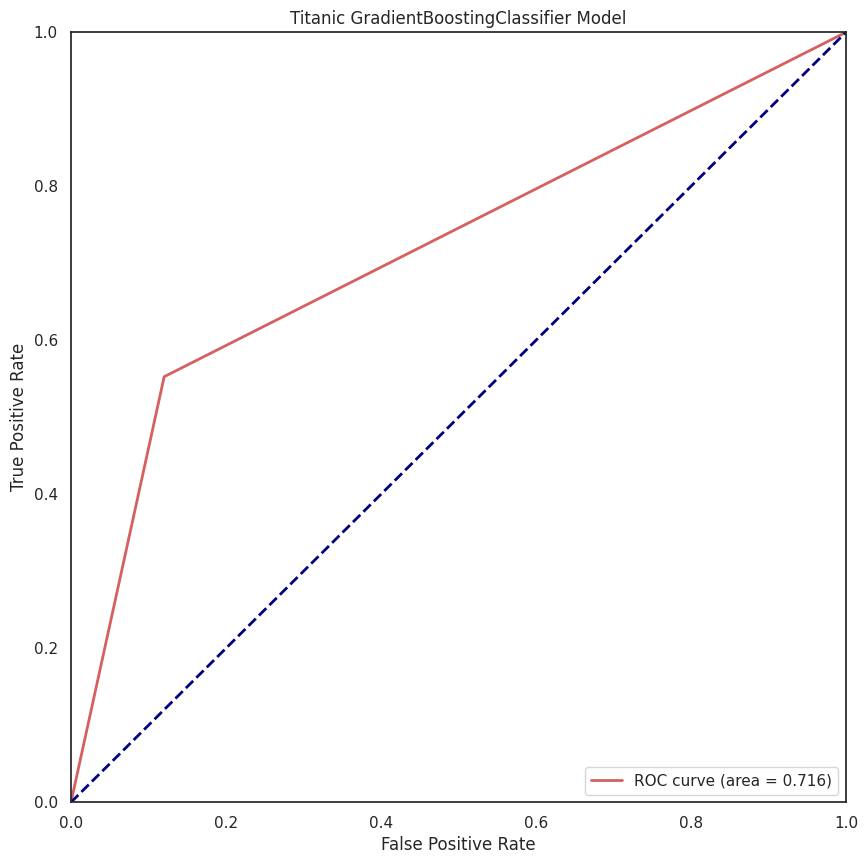

In [116]:
#查看模型ROC曲线
#求出测试数据模型的预测值
modelgsGBCtestpre_y = modelgsGBC.predict(experData_X).astype(int)

#画图
from sklearn.metrics import roc_curve, auc  ###计算roc和auc
# Compute ROC curve and ROC area for each class
fpr, tpr, threshold = roc_curve(experData_y, modelgsGBCtestpre_y)  ###计算真正率和假正率
roc_auc = auc(fpr, tpr)  ###计算auc的值

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, color='r',
         lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)  ###假正率为横坐标，真正率为纵坐标做曲线
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic GradientBoostingClassifier Model')
plt.legend(loc="lower right")
plt.show()

<Figure size 640x480 with 0 Axes>

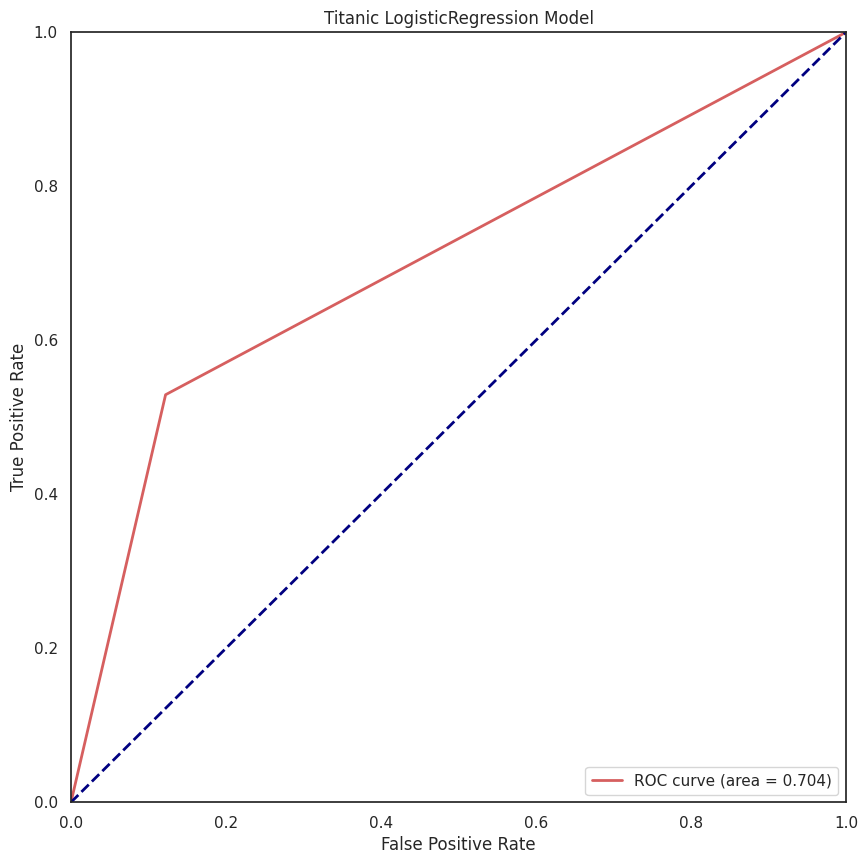

In [117]:
#查看模型ROC曲线
#求出测试数据模型的预测值
modelsLRtestpre_y = modelgsLR.predict(experData_X).astype(int)

#画图
from sklearn.metrics import roc_curve, auc  ###计算roc和auc
# Compute ROC curve and ROC area for each class
fpr, tpr, threshold = roc_curve(experData_y, modelsLRtestpre_y)  ###计算真正率和假正率
roc_auc = auc(fpr, tpr)  ###计算auc的值

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, color='r',
         lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)  ###假正率为横坐标，真正率为纵坐标做曲线
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic LogisticRegression Model')
plt.legend(loc="lower right")
plt.show()

<Figure size 640x480 with 0 Axes>

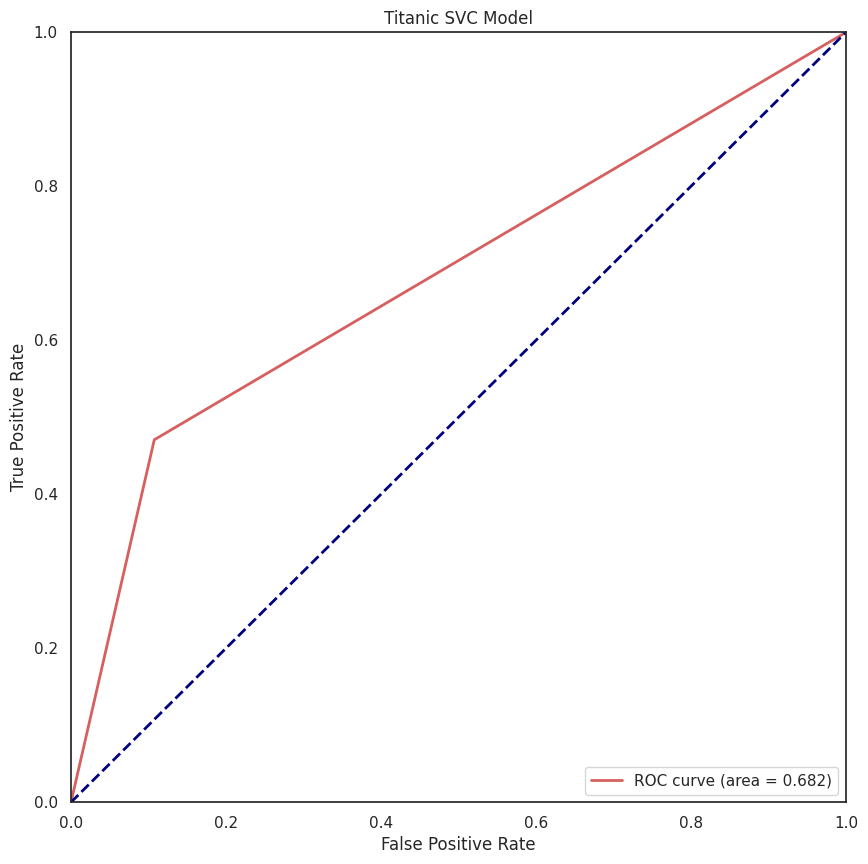

In [118]:
#查看模型ROC曲线
#求出测试数据模型的预测值
modelgsSVCtestpre_y = modelgsSVC.predict(experData_X).astype(int)

#画图
from sklearn.metrics import roc_curve, auc  ###计算roc和auc
# Compute ROC curve and ROC area for each class
fpr, tpr, threshold = roc_curve(experData_y, modelgsSVCtestpre_y)  ###计算真正率和假正率
roc_auc = auc(fpr, tpr)  ###计算auc的值

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, color='r',
         lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)  ###假正率为横坐标，真正率为纵坐标做曲线
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic SVC Model')
plt.legend(loc="lower right")
plt.show()

## 3.4 混淆矩阵 

In [119]:
#混淆矩阵
from sklearn.metrics import confusion_matrix
print('GradientBoostingClassifier模型混淆矩阵为\n', confusion_matrix(experData_y, modelgsGBCtestpre_y))
print('LogisticRegression模型混淆矩阵为\n', confusion_matrix(experData_y, modelsLRtestpre_y))
print('SVC模型混淆矩阵为\n', confusion_matrix(experData_y, modelgsSVCtestpre_y))

GradientBoostingClassifier模型混淆矩阵为
 [[483  66]
 [153 189]]
LogisticRegression模型混淆矩阵为
 [[482  67]
 [161 181]]
SVC模型混淆矩阵为
 [[490  59]
 [181 161]]


In [ ]:
hus in binary classification,the count of 
true negatives is:math:C_{0,0},

false negatives is:math:C_{1,0},

true positives is:math:C_{1,1},
and false positives is:math:C_{0,1},

In [121]:
#TitanicGBSmodule
# 使用最优GBC模型对测试集进行预测
y_ = modelgsGBC.predict(preData_X)
# 将预测结果转换为整型
y_ = y_.astype(int)

# 导出预测结果
GBCPreResultDf = pd.DataFrame()
# 从完整数据中取出测试集的PassengerId
GBCPreResultDf['PassengerId'] = full['PassengerId'][full['Survived'].isnull()]
# 赋值预测结果
GBCPreResultDf['Survived'] = y_
GBCPreResultDf
# 将预测结果导出为csv文件
GBCPreResultDf.to_csv('./lufengku_titanic.csv', index=False)
display(GBCPreResultDf.head())

,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,0


In [122]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
